# Notebook 07: Population Collapse Prediction

Under random mating, allele loss is inevitable in small populations. As alleles disappear, SI compatibility erodes, creating a **feedback loop**:

> Allele loss → fewer compatible mates → lower reproductive success → reduced effective population → faster allele loss

This cascade doesn't necessarily end in outright reproductive failure. Instead, populations settle into a **degraded equilibrium** — a handful of alleles remain, compatibility is low, and the population is genetically impoverished but still technically functional. From a conservation perspective, this degraded state *is* the collapse: the population has lost the genetic diversity it needs for long-term adaptation.

This notebook predicts **when** each population crosses the warning threshold, **when** it enters the degraded state, and visualizes the **intervention window** between the two.

**Prerequisites**: Run `00_load_data.ipynb` first.

In [1]:
import os
import sys
import pickle
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

sns.set_style("whitegrid")
np.random.seed(42)
random.seed(42)

sys.path.insert(0, "../src")
from polyploid_utils import *

In [2]:
with open("../data/population.pkl", "rb") as f:
    data = pickle.load(f)

population = data["population"]
pop_populations = data["pop_populations"]
allele_pool_full = data["allele_pool"]

# Major populations (>= 5 individuals)
major_pops = sorted([p for p, inds in pop_populations.items() if len(inds) >= 5])
print(f"Major populations: {major_pops}")
for p in major_pops:
    pop = pop_populations[p]
    alleles = set()
    for g in pop:
        alleles.update(g)
    print(f"  Pop {p}: N={len(pop)}, {len(alleles)} alleles")

Major populations: ['25', '27', '67', '76']
  Pop 25: N=31, 26 alleles
  Pop 27: N=15, 17 alleles
  Pop 67: N=22, 20 alleles
  Pop 76: N=27, 23 alleles


---
## Collapse Simulation

We run random mating for 150 generations across 30 replicates and track two key indicators each generation:

| Indicator | What it measures | Collapse signal |
|-----------|-----------------|----------------|
| **Allele count** | Unique alleles remaining | Diversity loss |
| **Mean compatibility** | Average pairwise SI compatibility | Mate availability |

We define two critical moments:
- **Warning threshold**: The generation when **25% of alleles are lost** — the early signal that diversity is eroding.
- **Degraded state**: The generation when **mean SI compatibility drops below 25%** — the population is functionally impoverished. Mate-finding is difficult, reproductive output is diminished, and long-term adaptive potential is severely compromised.

In tetraploid SI systems, populations don't necessarily go fully extinct. Instead they settle into a **degraded equilibrium** with a handful of alleles and chronically low compatibility. The gap between the warning and the degraded state is the **intervention window**.

Note: Population size is held constant (fixed at starting N) to isolate the genetic effects. Reproductive success remains near 100% even in degraded populations because enough compatible pairs exist to fill offspring quotas — the damage is genetic, not demographic.

In [3]:
ALLELE_WARN_FRAC = 0.75   # warning when alleles drop below 75% of initial
COMPAT_COLLAPSE = 0.25    # degraded state when mean compatibility < 25%

def run_collapse_simulation(pop, allele_pool, n_gen=150, n_replicates=30):
    """Run random mating for many generations and track collapse indicators.

    Returns a dict of arrays, each shape (n_replicates, n_gen+1), plus
    per-replicate threshold and collapse generation indices.
    """
    import random as _random
    N0 = len(pop)
    n_alleles_0 = len(allele_pool)

    results = {
        "allele_count": np.zeros((n_replicates, n_gen + 1)),
        "mean_compat": np.zeros((n_replicates, n_gen + 1)),
        "repro_success": np.ones((n_replicates, n_gen + 1)),
        "pop_size": np.zeros((n_replicates, n_gen + 1)),
        "warning_gen": np.full(n_replicates, np.nan),   # alleles < 75% of initial
        "degraded_gen": np.full(n_replicates, np.nan),   # compat < 25%
    }

    for rep in range(n_replicates):
        current_pop = list(pop)
        warning_hit = False
        degraded_hit = False

        for gen in range(n_gen + 1):
            N = len(current_pop)
            results["pop_size"][rep, gen] = N

            # Count surviving alleles
            present = set()
            for g in current_pop:
                present.update(g)
            n_alleles = len(present & set(allele_pool))
            results["allele_count"][rep, gen] = n_alleles

            # Mean pairwise compatibility (sample if population is large)
            if N >= 2:
                if N <= 40:
                    total_c, n_pairs = 0.0, 0
                    for i in range(N):
                        for j in range(N):
                            if i != j:
                                total_c += crossing_compatibility(
                                    current_pop[i], current_pop[j])
                                n_pairs += 1
                    mc = total_c / n_pairs if n_pairs > 0 else 0.0
                else:
                    sample_c, n_sample = 0.0, 500
                    for _ in range(n_sample):
                        i, j = _random.sample(range(N), 2)
                        sample_c += crossing_compatibility(
                            current_pop[i], current_pop[j])
                    mc = sample_c / n_sample
            else:
                mc = 0.0
            results["mean_compat"][rep, gen] = mc

            # Check warning (alleles < 75% of initial)
            if not warning_hit and n_alleles < n_alleles_0 * ALLELE_WARN_FRAC:
                results["warning_gen"][rep] = gen
                warning_hit = True

            # Check degraded state (compatibility < 25%)
            if not degraded_hit and gen > 0 and mc < COMPAT_COLLAPSE:
                results["degraded_gen"][rep] = gen
                degraded_hit = True

            # Advance generation
            if gen < n_gen and N >= 2:
                target = N0  # fixed population size
                next_gen = []
                attempts = 0
                max_attempts = target * 30
                while len(next_gen) < target and attempts < max_attempts:
                    i, j = _random.sample(range(N), 2)
                    child = sample_offspring(current_pop[i], current_pop[j])
                    if child is not None:
                        next_gen.append(child)
                    attempts += 1

                success_rate = len(next_gen) / target if target > 0 else 0.0
                results["repro_success"][rep, gen] = success_rate
                current_pop = next_gen if next_gen else current_pop

    return results

print("Collapse simulation function defined.")

Collapse simulation function defined.


In [4]:
N_GEN = 150
N_REPS = 30

collapse_data = {}

for pop_id in major_pops:
    pop = list(pop_populations[pop_id])
    alleles = set()
    for g in pop:
        alleles.update(g)
    alleles = sorted(alleles)
    N0 = len(pop)

    print(f"Simulating Pop {pop_id} (N={N0}, {len(alleles)} alleles)...")
    collapse_data[pop_id] = run_collapse_simulation(
        pop, alleles, n_gen=N_GEN, n_replicates=N_REPS,
    )

    res = collapse_data[pop_id]
    w_gen = res["warning_gen"]
    d_gen = res["degraded_gen"]
    w_hit = int(np.sum(~np.isnan(w_gen)))
    d_hit = int(np.sum(~np.isnan(d_gen)))
    w_med = f"median gen {np.nanmedian(w_gen):.0f}" if w_hit > 0 else "not reached"
    d_med = f"median gen {np.nanmedian(d_gen):.0f}" if d_hit > 0 else "not reached"
    print(f"  Warning  (75% alleles remain): {w_hit}/{N_REPS} replicates, {w_med}")
    print(f"  Degraded (compat < 25%):       {d_hit}/{N_REPS} replicates, {d_med}")
    print()

print("All simulations complete.")

Simulating Pop 25 (N=31, 26 alleles)...


  Warning  (75% alleles remain): 30/30 replicates, median gen 3
  Degraded (compat < 25%):       8/30 replicates, median gen 110

Simulating Pop 27 (N=15, 17 alleles)...


  Warning  (75% alleles remain): 30/30 replicates, median gen 5
  Degraded (compat < 25%):       30/30 replicates, median gen 16

Simulating Pop 67 (N=22, 20 alleles)...


  Warning  (75% alleles remain): 30/30 replicates, median gen 7
  Degraded (compat < 25%):       30/30 replicates, median gen 49

Simulating Pop 76 (N=27, 23 alleles)...


  Warning  (75% alleles remain): 30/30 replicates, median gen 4
  Degraded (compat < 25%):       22/30 replicates, median gen 90

All simulations complete.


---
## The Collapse Cascade

The figure below shows the trajectory from genetic erosion to degraded equilibrium for each population under unmanaged random mating. Each faded line is one replicate; the **bold solid line** is the median and the **bold dashed line** is the worst replicate (minimum alleles, minimum compatibility) at each generation.

The **amber zone** marks when the early warning is crossed (25% of alleles lost). The **red zone** marks when the degraded state is reached (mean compatibility < 25%). The gap between these zones is the **intervention window**. End-state values for both median and worst case are annotated on each panel.

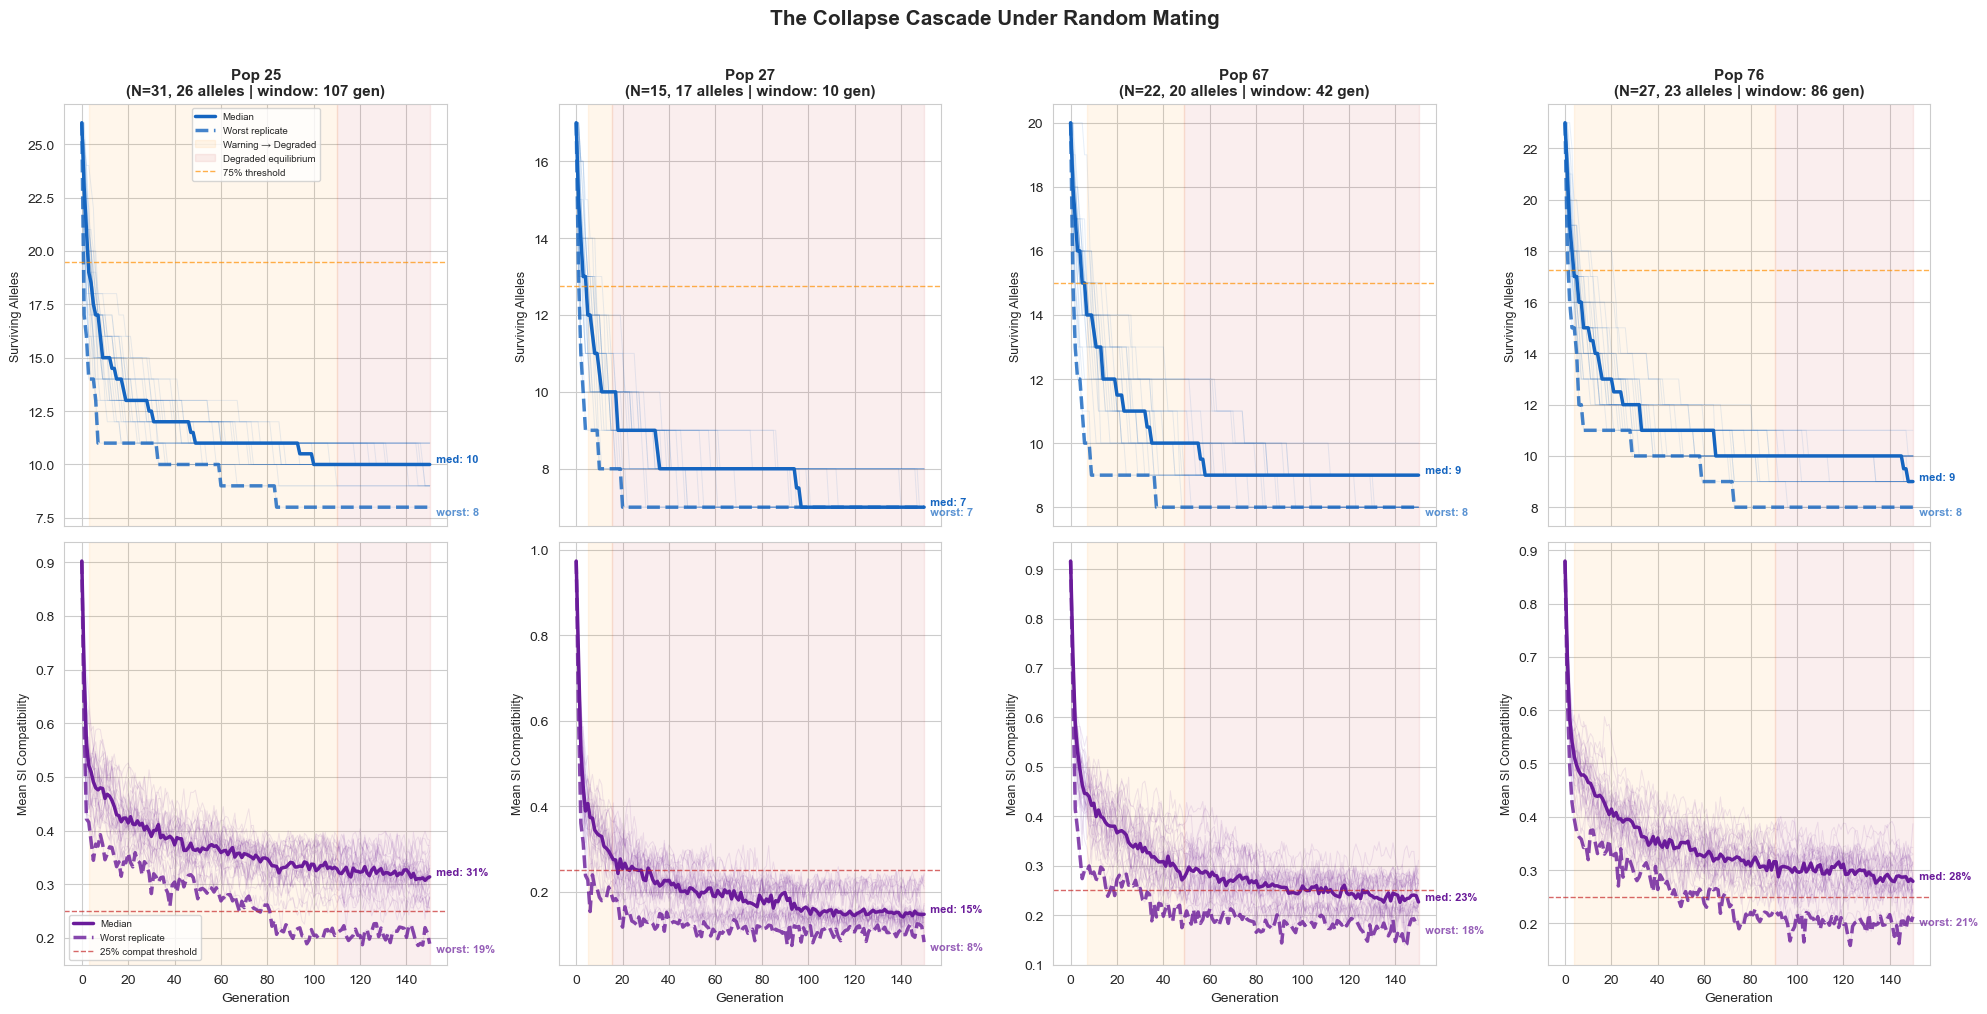

In [5]:
fig, axes = plt.subplots(2, len(major_pops), figsize=(5 * len(major_pops), 10),
                         sharex=True)

gens = np.arange(N_GEN + 1)

row_configs = [
    ("allele_count", "Surviving Alleles", "#1565c0"),
    ("mean_compat", "Mean SI Compatibility", "#6a1b9a"),
]

for col, pop_id in enumerate(major_pops):
    res = collapse_data[pop_id]
    pop = pop_populations[pop_id]
    n_alleles_0 = int(res["allele_count"][0, 0])
    w_gen = res["warning_gen"]
    d_gen = res["degraded_gen"]
    median_w = np.nanmedian(w_gen) if np.any(~np.isnan(w_gen)) else None
    median_d = np.nanmedian(d_gen) if np.any(~np.isnan(d_gen)) else None

    for row, (key, ylabel, color) in enumerate(row_configs):
        ax = axes[row, col]
        data_arr = res[key]

        # Plot individual replicates
        for rep in range(N_REPS):
            ax.plot(gens, data_arr[rep], color=color, alpha=0.1, linewidth=0.7)

        # Bold median line
        median_line = np.median(data_arr, axis=0)
        ax.plot(gens, median_line, color=color, linewidth=2.5, label="Median")

        # Bold worst-case line (minimum at each generation)
        worst_line = np.min(data_arr, axis=0)
        ax.plot(gens, worst_line, color=color, linewidth=2.5, linestyle="--",
                alpha=0.8, label="Worst replicate")

        # Shade warning and degraded zones
        if median_w is not None and median_d is not None and median_w < median_d:
            ax.axvspan(median_w, median_d, alpha=0.08, color="#ff8f00",
                       label="Warning → Degraded" if row == 0 else None)
            ax.axvspan(median_d, N_GEN, alpha=0.08, color="#c62828",
                       label="Degraded equilibrium" if row == 0 else None)
        elif median_w is not None:
            ax.axvspan(median_w, N_GEN, alpha=0.08, color="#ff8f00",
                       label="Post-warning" if row == 0 else None)

        # Reference lines
        if key == "allele_count":
            ax.axhline(n_alleles_0 * ALLELE_WARN_FRAC, color="#ff8f00",
                       linestyle="--", linewidth=1, alpha=0.7, label="75% threshold")
        if key == "mean_compat":
            ax.axhline(COMPAT_COLLAPSE, color="#c62828", linestyle="--",
                       linewidth=1, alpha=0.7, label="25% compat threshold")

        # End-state annotations: median and worst
        end_med = np.median(data_arr[:, -1])
        end_worst = np.min(data_arr[:, -1])
        if key == "allele_count":
            ax.annotate(f"  med: {end_med:.0f}",
                        xy=(N_GEN, end_med), fontsize=8, color=color,
                        fontweight="bold", va="bottom")
            ax.annotate(f"  worst: {end_worst:.0f}",
                        xy=(N_GEN, end_worst), fontsize=8, color=color,
                        fontweight="bold", va="top", alpha=0.7)
        elif key == "mean_compat":
            ax.annotate(f"  med: {end_med:.0%}",
                        xy=(N_GEN, end_med), fontsize=8, color=color,
                        fontweight="bold", va="bottom")
            ax.annotate(f"  worst: {end_worst:.0%}",
                        xy=(N_GEN, end_worst), fontsize=8, color=color,
                        fontweight="bold", va="top", alpha=0.7)

        ax.set_ylabel(ylabel, fontsize=9)
        if row == 0:
            window_txt = ""
            if median_w is not None and median_d is not None:
                window_txt = f" | window: {median_d - median_w:.0f} gen"
            ax.set_title(f"Pop {pop_id}\n(N={len(pop)}, {n_alleles_0} alleles{window_txt})",
                         fontsize=11, fontweight="bold")
        if row == 1:
            ax.set_xlabel("Generation", fontsize=10)
        if col == 0:
            ax.legend(fontsize=7, loc="best")

plt.suptitle("The Collapse Cascade Under Random Mating",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../figures/collapse_cascade.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Survival Curves: When Does Each Population Fail?

Kaplan-Meier-style curves showing what fraction of replicates have **not yet** crossed each threshold by a given generation. Steeper drops mean faster, more certain collapse.

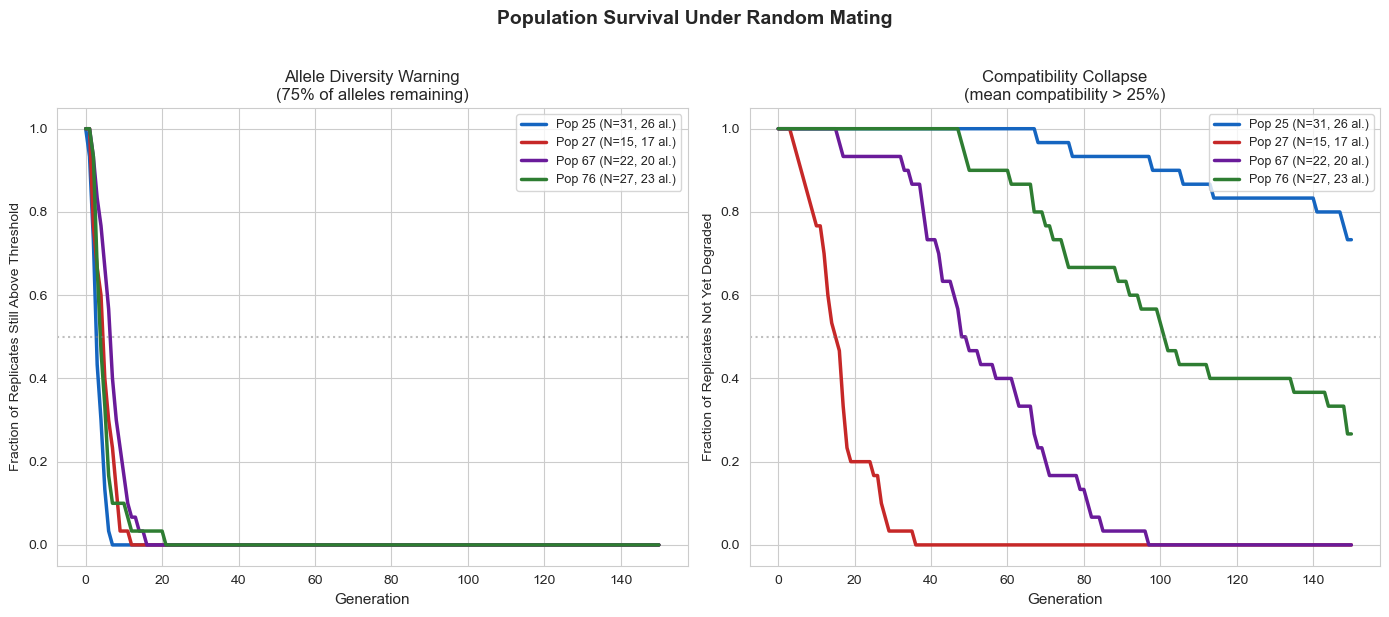

In [6]:
pop_colors = {"25": "#1565c0", "27": "#c62828", "67": "#6a1b9a", "76": "#2e7d32"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for pop_id in major_pops:
    res = collapse_data[pop_id]
    color = pop_colors.get(pop_id, "gray")
    N0 = len(pop_populations[pop_id])
    n_alleles_0 = int(res["allele_count"][0, 0])

    # Warning survival (alleles still > 75%)
    w_gen = res["warning_gen"]
    survival_w = np.array([
        np.sum((np.isnan(w_gen)) | (w_gen > g)) / N_REPS
        for g in gens
    ])
    ax1.plot(gens, survival_w, color=color, linewidth=2.5,
             label=f"Pop {pop_id} (N={N0}, {n_alleles_0} al.)")

    # Degraded survival (compat still > 25%)
    d_gen = res["degraded_gen"]
    survival_d = np.array([
        np.sum((np.isnan(d_gen)) | (d_gen > g)) / N_REPS
        for g in gens
    ])
    ax2.plot(gens, survival_d, color=color, linewidth=2.5,
             label=f"Pop {pop_id} (N={N0}, {n_alleles_0} al.)")

ax1.set_xlabel("Generation", fontsize=11)
ax1.set_ylabel("Fraction of Replicates Still Above Threshold", fontsize=10)
ax1.set_title("Allele Diversity Warning\n(75% of alleles remaining)", fontsize=12)
ax1.legend(fontsize=9)
ax1.set_ylim(-0.05, 1.05)
ax1.axhline(0.5, color="gray", linestyle=":", alpha=0.5)

ax2.set_xlabel("Generation", fontsize=11)
ax2.set_ylabel("Fraction of Replicates Not Yet Degraded", fontsize=10)
ax2.set_title("Compatibility Collapse\n(mean compatibility > 25%)", fontsize=12)
ax2.legend(fontsize=9)
ax2.set_ylim(-0.05, 1.05)
ax2.axhline(0.5, color="gray", linestyle=":", alpha=0.5)

plt.suptitle("Population Survival Under Random Mating",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/survival_curves.png", dpi=200, bbox_inches="tight")
plt.show()

---
## The Intervention Window

For the most vulnerable population, a single annotated panel showing the full cascade from healthy to degraded equilibrium. Three normalized curves — allele diversity, SI compatibility, and reproductive success — decline in sequence, revealing the causal chain. The gap between the warning and the degraded state is the window for conservation action.

In [7]:
# Find the most urgently vulnerable population (earliest median degraded state)
earliest_d = None
target_pop = None
for pop_id in major_pops:
    d = collapse_data[pop_id]["degraded_gen"]
    med = np.nanmedian(d) if np.any(~np.isnan(d)) else np.inf
    if earliest_d is None or med < earliest_d:
        earliest_d = med
        target_pop = pop_id

res = collapse_data[target_pop]
pop = pop_populations[target_pop]
n_alleles_0 = int(res["allele_count"][0, 0])
N0 = len(pop)

w_gen = res["warning_gen"]
d_gen = res["degraded_gen"]
median_w = np.nanmedian(w_gen) if np.any(~np.isnan(w_gen)) else None
median_d = np.nanmedian(d_gen) if np.any(~np.isnan(d_gen)) else None

print(f"Most urgently vulnerable: Pop {target_pop} (N={N0}, {n_alleles_0} alleles)")
print(f"  Median warning generation:  {median_w}")
print(f"  Median degraded generation: {median_d}")
if median_w is not None and median_d is not None:
    print(f"  Intervention window: ~{median_d - median_w:.0f} generations")

Most urgently vulnerable: Pop 27 (N=15, 17 alleles)
  Median warning generation:  5.0
  Median degraded generation: 15.5
  Intervention window: ~10 generations


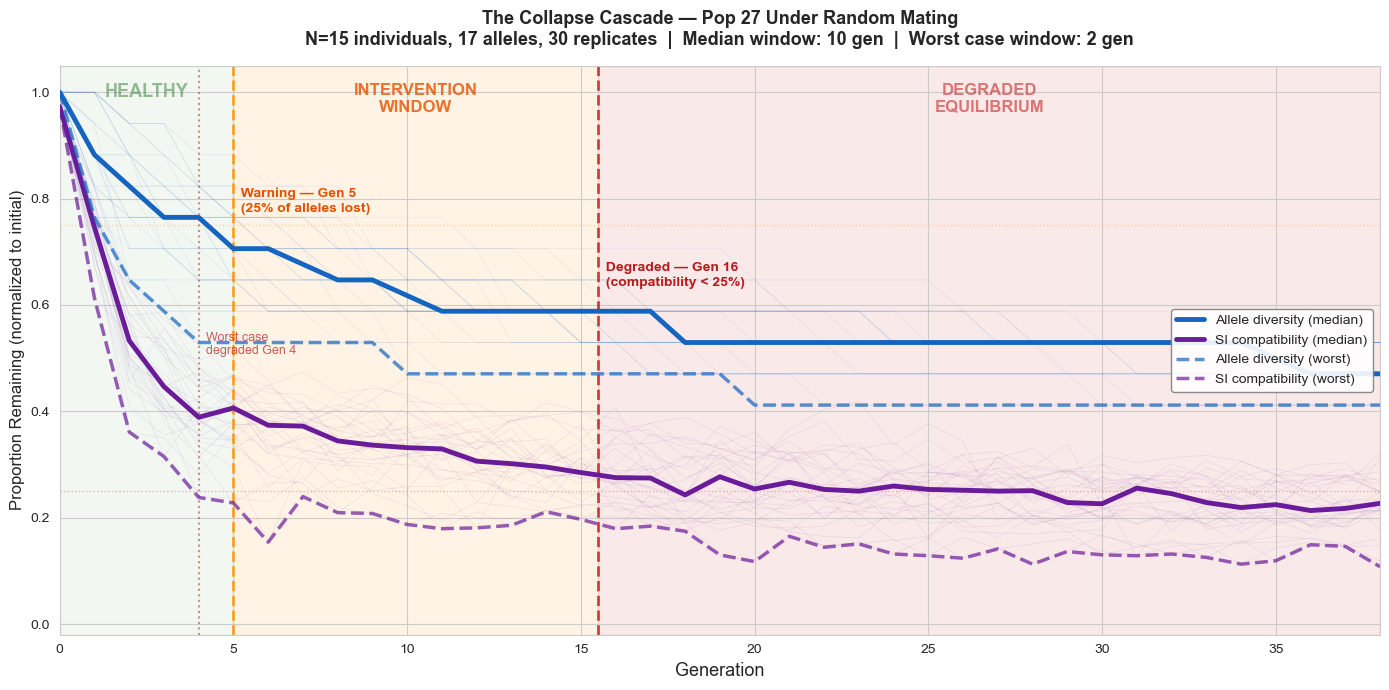

In [8]:
fig, ax_main = plt.subplots(figsize=(14, 7))

# Zoom to show the action — up to 2x the degraded generation or full sim
x_max = min(N_GEN, int((median_d or N_GEN) * 2.5))
gens_plot = np.arange(x_max + 1)

# Normalize allele count to 0-1 for overlay
allele_norm = res["allele_count"][:, :x_max+1] / n_alleles_0
compat_data = res["mean_compat"][:, :x_max+1]

# --- Background zones ---
if median_w is not None:
    ax_main.axvspan(0, median_w, alpha=0.06, color="#2e7d32", zorder=0)
    ax_main.text(max(median_w / 2, 1), 0.97, "HEALTHY", ha="center", va="top",
                 fontsize=13, color="#2e7d32", fontweight="bold", alpha=0.5,
                 transform=ax_main.get_xaxis_transform())

if median_w is not None and median_d is not None:
    ax_main.axvspan(median_w, median_d, alpha=0.10, color="#ff8f00", zorder=0)
    mid_warn = (median_w + median_d) / 2
    ax_main.text(mid_warn, 0.97, "INTERVENTION\nWINDOW", ha="center", va="top",
                 fontsize=12, color="#e65100", fontweight="bold", alpha=0.8,
                 transform=ax_main.get_xaxis_transform())

    ax_main.axvspan(median_d, x_max, alpha=0.10, color="#c62828", zorder=0)
    mid_deg = (median_d + x_max) / 2
    ax_main.text(mid_deg, 0.97, "DEGRADED\nEQUILIBRIUM", ha="center", va="top",
                 fontsize=12, color="#c62828", fontweight="bold", alpha=0.6,
                 transform=ax_main.get_xaxis_transform())

# --- Replicate traces ---
for rep in range(N_REPS):
    ax_main.plot(gens_plot, allele_norm[rep], color="#1565c0", alpha=0.08, linewidth=0.6)
    ax_main.plot(gens_plot, compat_data[rep], color="#6a1b9a", alpha=0.08, linewidth=0.6)

# --- Median lines ---
med_allele = np.median(allele_norm, axis=0)
med_compat = np.median(compat_data, axis=0)

ax_main.plot(gens_plot, med_allele, color="#1565c0", linewidth=3.5,
             label="Allele diversity (median)", zorder=5)
ax_main.plot(gens_plot, med_compat, color="#6a1b9a", linewidth=3.5,
             label="SI compatibility (median)", zorder=5)

# --- Worst-case lines ---
worst_allele = np.min(allele_norm, axis=0)
worst_compat = np.min(compat_data, axis=0)

ax_main.plot(gens_plot, worst_allele, color="#1565c0", linewidth=2.5,
             linestyle="--", alpha=0.7, label="Allele diversity (worst)", zorder=5)
ax_main.plot(gens_plot, worst_compat, color="#6a1b9a", linewidth=2.5,
             linestyle="--", alpha=0.7, label="SI compatibility (worst)", zorder=5)

# --- Threshold markers ---
if median_w is not None:
    ax_main.axvline(median_w, color="#ff8f00", linestyle="--", linewidth=2, alpha=0.8)
    ax_main.annotate(f"  Warning — Gen {median_w:.0f}\n  (25% of alleles lost)",
                     xy=(median_w, 0.82),
                     fontsize=10, color="#e65100", fontweight="bold",
                     ha="left", va="top")

if median_d is not None:
    ax_main.axvline(median_d, color="#b71c1c", linestyle="--", linewidth=2, alpha=0.8)
    ax_main.annotate(f"  Degraded — Gen {median_d:.0f}\n  (compatibility < 25%)",
                     xy=(median_d, 0.68),
                     fontsize=10, color="#b71c1c", fontweight="bold",
                     ha="left", va="top")

# --- Worst-case earliest degraded generation ---
worst_d = np.nanmin(d_gen) if np.any(~np.isnan(d_gen)) else None
if worst_d is not None and worst_d < median_d:
    ax_main.axvline(worst_d, color="#b71c1c", linestyle=":", linewidth=1.5, alpha=0.5)
    ax_main.annotate(f"  Worst case\n  degraded Gen {worst_d:.0f}",
                     xy=(worst_d, 0.55),
                     fontsize=9, color="#b71c1c", alpha=0.7,
                     ha="left", va="top")

# --- Reference lines ---
ax_main.axhline(ALLELE_WARN_FRAC, color="#ff8f00", linestyle=":", alpha=0.3, linewidth=1)
ax_main.axhline(COMPAT_COLLAPSE, color="#c62828", linestyle=":", alpha=0.3, linewidth=1)

# --- Formatting ---
ax_main.set_xlim(0, x_max)
ax_main.set_ylim(-0.02, 1.05)
ax_main.set_xlabel("Generation", fontsize=13)
ax_main.set_ylabel("Proportion Remaining (normalized to initial)", fontsize=12)

worst_window = ""
if worst_d is not None:
    worst_w = np.nanmin(w_gen) if np.any(~np.isnan(w_gen)) else None
    if worst_w is not None:
        worst_window = f"  |  Worst case window: {worst_d - worst_w:.0f} gen"

ax_main.set_title(
    f"The Collapse Cascade — Pop {target_pop} Under Random Mating\n"
    f"N={N0} individuals, {n_alleles_0} alleles, {N_REPS} replicates  |  "
    f"Median window: {median_d - median_w:.0f} gen{worst_window}",
    fontsize=13, fontweight="bold", pad=15)

ax_main.legend(fontsize=10, loc="center right",
               framealpha=0.9, edgecolor="gray")

plt.tight_layout()
plt.savefig("../figures/intervention_window.png", dpi=250, bbox_inches="tight")
plt.show()

---
## Summary Table

In [9]:
rows = []
for pop_id in major_pops:
    res = collapse_data[pop_id]
    N0 = len(pop_populations[pop_id])
    n_al = int(res["allele_count"][0, 0])
    w_gen = res["warning_gen"]
    d_gen = res["degraded_gen"]
    w_pct = np.sum(~np.isnan(w_gen)) / N_REPS * 100
    d_pct = np.sum(~np.isnan(d_gen)) / N_REPS * 100
    med_w = np.nanmedian(w_gen) if np.any(~np.isnan(w_gen)) else None
    med_d = np.nanmedian(d_gen) if np.any(~np.isnan(d_gen)) else None
    worst_w = np.nanmin(w_gen) if np.any(~np.isnan(w_gen)) else None
    worst_d = np.nanmin(d_gen) if np.any(~np.isnan(d_gen)) else None
    window = (med_d - med_w) if (med_w is not None and med_d is not None) else None
    worst_window = (worst_d - worst_w) if (worst_w is not None and worst_d is not None) else None

    # End-state metrics (final generation)
    al_end_med = np.median(res["allele_count"][:, -1])
    al_end_worst = np.min(res["allele_count"][:, -1])
    mc_end_med = np.median(res["mean_compat"][:, -1])
    mc_end_worst = np.min(res["mean_compat"][:, -1])

    rows.append({
        "Pop": pop_id,
        "N": N0,
        "Alleles": n_al,
        "Warn Gen (med)": f"{med_w:.0f}" if med_w is not None else "--",
        "Warn Gen (worst)": f"{worst_w:.0f}" if worst_w is not None else "--",
        "Degraded Gen (med)": f"{med_d:.0f}" if med_d is not None else "--",
        "Degraded Gen (worst)": f"{worst_d:.0f}" if worst_d is not None else "--",
        "Window (med)": f"{window:.0f}" if window is not None else "--",
        "Window (worst)": f"{worst_window:.0f}" if worst_window is not None else "--",
        f"Alleles @{N_GEN} (med/worst)": f"{al_end_med:.0f} / {al_end_worst:.0f}",
        f"Compat @{N_GEN} (med/worst)": f"{mc_end_med:.2f} / {mc_end_worst:.2f}",
    })

summary_df = pd.DataFrame(rows)
print(f"Collapse Prediction Summary (Random Mating, Fixed Population Size)")
print(f"Simulation: {N_GEN} generations, {N_REPS} replicates per population")
print("=" * 150)
print(summary_df.to_string(index=False))
print(f"\nWarning = alleles drop below {ALLELE_WARN_FRAC*100:.0f}% of initial")
print(f"Degraded = mean SI compatibility drops below {COMPAT_COLLAPSE*100:.0f}%")
print("Window = generations between early warning and degraded state")
print("Worst = single worst replicate across all runs")

Collapse Prediction Summary (Random Mating, Fixed Population Size)
Simulation: 150 generations, 30 replicates per population
Pop  N  Alleles Warn Gen (med) Warn Gen (worst) Degraded Gen (med) Degraded Gen (worst) Window (med) Window (worst) Alleles @150 (med/worst) Compat @150 (med/worst)
 25 31       26              3                1                110                   68          107             67                   10 / 8             0.31 / 0.19
 27 15       17              5                2                 16                    4           10              2                    7 / 7             0.15 / 0.08
 67 22       20              7                2                 49                   16           42             14                    9 / 8             0.23 / 0.18
 76 27       23              4                2                 90                   48           86             46                    9 / 8             0.28 / 0.21

Warning = alleles drop below 75% of initial
Degra

---
## Factors and Parameters Affecting Collapse Timing

The speed at which a population degrades under random mating depends on several interacting factors. Understanding these drivers helps managers prioritize which populations need intervention most urgently.

### Population-level factors

| Factor | Effect on collapse timing | Why |
|--------|--------------------------|-----|
| **Population size (N)** | Smaller N → faster collapse | Fewer individuals = fewer allele copies = higher drift. Pop 27 (N=15) degrades by gen 16; Pop 25 (N=31) takes ~110 generations. |
| **Initial allele count** | Fewer alleles → faster collapse | Less redundancy means each allele loss has a larger proportional impact on compatibility. |
| **Allele frequency distribution** | More singletons → faster collapse | Alleles carried by only 1–2 individuals are lost first. Populations with many singletons lose diversity faster. |
| **Starting compatibility** | Lower initial compatibility → faster collapse | Populations that already have restricted mate availability are closer to the degraded threshold. |

### Simulation parameters

| Parameter | Default | Effect |
|-----------|---------|--------|
| `ALLELE_WARN_FRAC` | 0.75 | Warning triggers when alleles drop below 75% of initial count. Lower values delay the warning signal. |
| `COMPAT_COLLAPSE` | 0.25 | Degraded state triggers when mean SI compatibility falls below 25%. Higher values widen the intervention window but flag populations earlier. |
| `n_gen` | 150 | Total generations simulated. Must be long enough for slow-collapsing populations to reach equilibrium. |
| `n_replicates` | 30 | Number of stochastic replicates. More replicates give smoother survival curves and more reliable median estimates. |
| `N0` (fixed) | Starting N | Population size is held constant — offspring target equals starting size each generation. This isolates the effect of allele loss from demographic decline. |

### The cascade mechanism

Collapse is not a single event but a **sequential process** with compounding feedback:

1. **Allele erosion** (generations 1–10): Rare alleles (singletons, doubletons) are lost through random sampling. Each loss is small individually but cumulative.
2. **Compatibility decline** (generations 5–30): As alleles disappear, more mating pairs share alleles and become SI-incompatible. Mean compatibility drops.
3. **Reproductive stress** (generations 20–50+): With fewer compatible mates, more mating attempts fail. Reproductive success drops, though populations with fixed size targets compensate by attempting more crosses.
4. **Degraded equilibrium** (generation 15–110+): The population stabilizes with ~7–10 alleles and 15–30% compatibility. Further allele loss slows because the remaining alleles are now common enough to resist drift. The population is stable but genetically impoverished.

The **nonlinear feedback** between steps 1 and 2 is critical: allele loss reduces compatibility, which concentrates reproduction among fewer compatible pairs, which further homogenizes allele frequencies, which accelerates the next round of allele loss.

---
## Worst Case: Population 27

**Pop 27 is the most vulnerable population in the dataset and demands the most urgent conservation attention.**

| Metric | Pop 27 | Next worst (Pop 67) |
|--------|--------|---------------------|
| Population size | **15** (smallest) | 22 |
| Initial alleles | **17** (fewest) | 20 |
| Alleles per individual | 4 (fixed by ploidy) | 4 |
| Allele redundancy (copies per allele) | **3.5** (15×4/17) | 4.4 |
| Median warning generation | **5** | 7 |
| Median degraded generation | **16** | 49 |
| Intervention window | **~10 generations** | ~42 generations |
| Replicates reaching degraded state | **100%** (30/30) | 100% (30/30) |
| Alleles remaining at gen 150 | **~7** | ~9 |
| Final compatibility | **~15%** | ~23% |

### Why Pop 27 collapses so fast

1. **Minimal redundancy**: With only 3.5 allele copies on average (vs. 4.8 for Pop 25), even a single individual's failure to reproduce can permanently eliminate an allele.
2. **Small population amplifies drift**: At N=15, random sampling variance is ~2× higher than at N=31. Rare alleles have less "insurance" against stochastic loss.
3. **Rapid feedback**: Because Pop 27 starts with fewer alleles, each loss removes a larger fraction of total diversity (~6% per allele vs. ~4% for Pop 25). This accelerates the compatibility decline, which in turn accelerates further allele loss.
4. **No recovery**: Once an allele is lost, it cannot return. By generation 16, the population has lost enough alleles that compatibility is permanently below 25%.

### Conservation implication

Pop 27's intervention window of ~10 generations means that **if management does not begin within 5 generations of observing the first allele losses, the population will reach a degraded state from which recovery without gene flow from other populations is impossible.** This population should be the highest priority for managed crossing strategies.